In [1]:
!pip3 install pandas matplotlib seaborn

In [2]:
!pip3 install scikit-learn tensorflow keras


  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.3.25-py2.py3-none-any.whl.metadata (850 bytes)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached wheel-0.42.0-py3-none-any.whl.metadata (2.2 kB)
   --------------------------------------- 266.3/266.3 MB 13.4 MB/s eta 0:00:00
   ---------------------------------------- 1.7/1.7 MB 13.4 MB/s eta 0:00:00
Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached flatbuffers-24.3.25-py2.py3-none-any.whl (26 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ---------------------------------------- 4.5/4.5 MB 40.9 MB/s eta 0:00:00
   ---------------------------------------- 2.6/2.6 MB 2.2 MB/s eta 0:00:00
Using cached libclang-18.1.1-py2.py3

In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential

In [ ]:
input_files = [
    "bent-over_rows",
    "biceps",
    "latheral_raises",
    "rdl",
    "shoulder_press",
    "squat_front",
    "squat_side"
]


In [ ]:
import os
import json
import pandas as pd

# Fájlok beolvasása
base_path= r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames"

# Eredmény DataFrame inicializálása
data_rows = []
for file_name in input_files:
    for i in range(0,1):
        # JSON fájl betöltése
        file_path = os.path.join(base_path, file_name, f"{i}.json")
        with open(file_path, "r") as f:
            data = json.load(f)

        video_name = data["video_name"]

        for frame in data["frames"]:
            frame_number = frame["frame_number"]

            # Kulcspontok lapítása
            keypoints = frame["keypoints"]
            flattened_features = []
            for keypoint in keypoints:
                flattened_features.extend([
                    keypoint["x"],
                    keypoint["y"],
                    keypoint["depth"],
                    keypoint["confidence"]
                ])

            # Sor hozzáadása a DataFrame-hez
            data_rows.append({
                "video_name": video_name,
                "frame_number": frame_number,
                **{f"feature_{i+1}": feature for i, feature in enumerate(flattened_features)}
            })

# DataFrame létrehozása
df = pd.DataFrame(data_rows)

# DataFrame mentése CSV formátumba
output_file = "svm_ready_data.csv"
df.to_csv(output_file, index=False)

print(f"Adatok mentve: {output_file}")
df


Adatok mentve: svm_ready_data.csv


,video_name,frame_number,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100
0,bent-over_rows,1,258.269300,143.258800,2542,0.897225,296.762177,181.506600,2417,0.885340,...,0,0.286052,318.622650,403.683838,0,0.274050,359.792800,409.134100,3493,0.315296
1,bent-over_rows,2,258.282532,145.808243,2542,0.890022,296.706238,181.549255,2417,0.903342,...,0,0.202670,318.640167,406.378540,0,0.205381,362.450867,406.349400,0,0.339444
2,bent-over_rows,3,255.579575,145.954483,2542,0.883411,296.647247,184.126465,2417,0.921508,...,0,0.173954,318.633118,411.850159,0,0.177791,359.805817,414.561100,0,0.316815
3,bent-over_rows,4,255.614532,154.067169,2542,0.861824,296.595428,184.252884,2417,0.922364,...,0,0.179250,318.552734,417.324300,0,0.180844,359.757843,422.749237,0,0.336228
4,bent-over_rows,5,252.887741,156.833862,2542,0.909741,296.644200,184.205521,2417,0.908717,...,0,0.135929,318.514038,422.738617,0,0.135335,359.715637,417.362549,0,0.221421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,squat_side,72,384.592255,230.830078,2701,0.821352,343.315600,233.592789,2289,0.805741,...,2743,0.466463,326.850677,447.582916,0,0.510551,302.141449,431.136900,2434,0.774208
528,squat_side,73,389.980316,247.310974,2659,0.567182,346.066600,255.623200,2434,0.752559,...,0,0.492837,321.344700,450.196100,0,0.540531,296.728638,433.824463,2469,0.802028
529,squat_side,74,387.236023,252.839981,2639,0.868285,354.215200,266.536200,2523,0.724343,...,2722,0.553761,318.680600,450.135254,2722,0.576540,296.727966,431.135681,2469,0.748865
530,squat_side,75,384.484283,255.646988,2639,0.816486,346.050400,274.737976,2274,0.723069,...,0,0.506706,318.641479,447.507172,0,0.543207,299.372375,428.438721,2434,0.745120


In [ ]:
motions= pd.DataFrame()
base_path= r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames"
for file_name in input_files:
    for i in range(0,1):
        file_path = os.path.join(base_path, file_name, f"{i}.json")



        # raw_data =pd.read_json(fr"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames\{file_name}\{i}")
        # with open(r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames\rdl\0.json", "r") as f:
        with open(file_path, "r") as f:
            motions= pd.concat([motions, pd.read_json(f)])
            

motions
                

,video_name,frames
0,bent-over_rows,"{'frame_number': 1, 'keypoints': [{'x': 258.26..."
1,bent-over_rows,"{'frame_number': 2, 'keypoints': [{'x': 258.28..."
2,bent-over_rows,"{'frame_number': 3, 'keypoints': [{'x': 255.57..."
3,bent-over_rows,"{'frame_number': 4, 'keypoints': [{'x': 255.61..."
4,bent-over_rows,"{'frame_number': 5, 'keypoints': [{'x': 252.88..."
...,...,...
71,squat_side,"{'frame_number': 72, 'keypoints': [{'x': 384.5..."
72,squat_side,"{'frame_number': 73, 'keypoints': [{'x': 389.9..."
73,squat_side,"{'frame_number': 74, 'keypoints': [{'x': 387.2..."
74,squat_side,"{'frame_number': 75, 'keypoints': [{'x': 384.4..."


In [ ]:
encoder= LabelEncoder()
df_encoded = encoder.fit_transform(motions['video_name'])
Y= df_encoded
X= df.drop('video_name', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# timesteps = 50  # Példa időlépésszám
# features = 25 * 4  # Minden ízület x, y, depth, confidence adata

# X_train = X_train.reshape(-1, timesteps, features)
# X_test = X_test.reshape(-1, timesteps, features)


In [ ]:
print(f"X_train alakja: {X_train.shape}, y_train alakja: {y_train.shape}")



X_train alakja: (425, 101), y_train alakja: (425,)


In [ ]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred= svm_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(accuracy)
print(class_report)

0.7663551401869159
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        20
           1       0.61      0.89      0.72        19
           2       0.80      0.57      0.67        14
           3       0.67      1.00      0.80        12
           4       0.60      0.55      0.57        11
           5       0.89      0.57      0.70        14
           6       0.94      1.00      0.97        17

    accuracy                           0.77       107
   macro avg       0.79      0.75      0.75       107
weighted avg       0.80      0.77      0.76       107



In [ ]:
from sklearn.model_selection import GridSearchCV


param_dist = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.001, 0.005, 0.1, 0.5, 1],  # Véletlen C értékek 0.1 és 10 között
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(SVC(), param_grid=param_dist, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)




GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.005, 0.1, 0.5, 1],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

In [ ]:
print("Legjobb paraméterek:", grid_search.best_params_)
print("Legjobb pontosság (CV):", grid_search.best_score_)


Legjobb paraméterek: {'C': 0.001, 'gamma': 'scale', 'kernel': 'linear'}
Legjobb pontosság (CV): 0.9458823529411765


In [ ]:
svm= grid_search.best_estimator_

svm.fit(X_train, y_train)
y_pred=svm.predict(X_test)



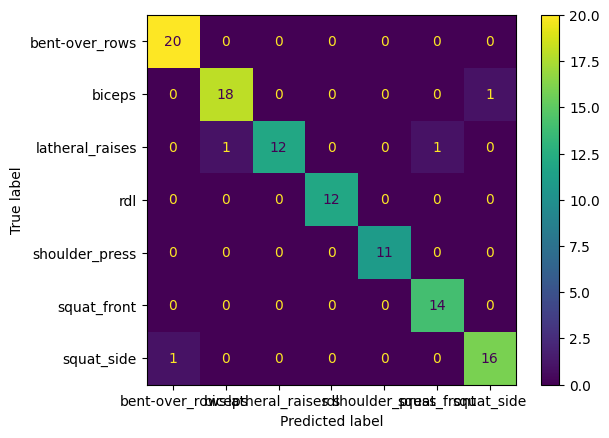

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Konfúziós mátrix
cm = confusion_matrix(y_test, y_pred)

# Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=input_files)
disp.plot(cmap="viridis")

plt.tight_layout
plt.show()


In [ ]:
from joblib import dump


dump(grid_search.best_estimator_, "svm_model.joblib")



['svm_model.joblib']

In [ ]:
from joblib import load

# A modell betöltése
loaded_model = load('svm_model.joblib')
print("Modell betöltve.")

# A modell használata
accuracy = loaded_model.score(X_test, y_test)
print(f'Teszthalmaz pontossága: {accuracy:.2f}')



Modell betöltve.
Teszthalmaz pontossága: 0.96


In [ ]:
y_pred=loaded_model.predict(X_test)

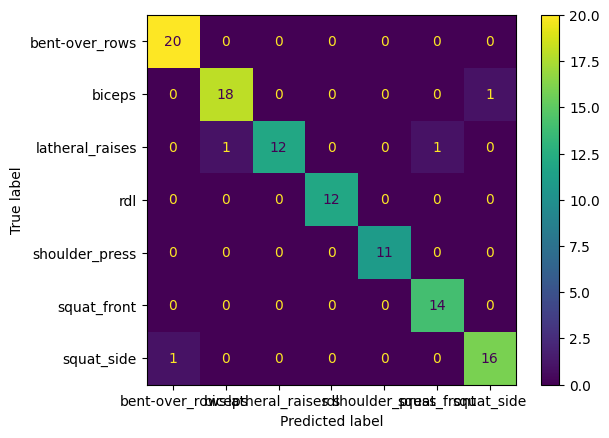

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=input_files)
disp.plot(cmap="viridis")

plt.tight_layout
plt.show()